In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('Final_Dataset/Final_dataset.csv')


,datetime,pm2.5,pm10,tsp,temp,humidity,windspeed,winddir,sealevelpressure,visibility,precipitation,solarradiation,aqi,aqi_category
0,2016-08-25,24.106910,131.608300,407.084300,77.7,75.7,9.2,226.8,1014.0,4.9,0.0,232.3,89.0,Moderate
1,2016-08-26,20.384295,111.050740,389.271000,74.5,81.3,12.8,171.4,1015.7,4.9,15.5,231.4,79.0,Moderate
2,2016-08-27,16.661680,90.493180,371.457700,77.9,77.4,6.9,162.2,1016.0,5.1,0.0,260.2,69.0,Moderate
3,2016-08-28,31.365190,86.597780,256.126600,75.8,78.8,10.3,223.2,1015.8,5.3,0.0,229.8,92.0,Moderate
4,2016-08-29,35.661620,54.458180,101.626100,74.6,81.8,9.2,289.3,1013.1,4.7,0.5,190.1,101.0,Unhealthy for Sensitive Groups
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2641,2024-12-27,90.031286,122.154243,161.637471,52.5,69.4,4.7,160.8,1024.1,3.7,0.0,175.9,169.0,Unhealthy
2642,2024-12-28,115.462085,150.554242,191.303695,51.5,76.6,4.7,131.1,1023.8,2.8,2.0,67.2,182.0,Unhealthy
2643,2024-12-29,104.691319,139.022639,201.824028,54.8,68.3,11.4,257.4,1021.4,3.3,1.6,137.5,176.0,Unhealthy
2644,2024-12-30,81.418264,107.658472,139.620417,52.4,71.1,8.1,204.3,1020.5,4.1,0.0,150.8,164.0,Unhealthy


In [3]:
df_copy = df
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2646 entries, 0 to 2645
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   datetime          2646 non-null   object 
 1   pm2.5             2646 non-null   float64
 2   pm10              2646 non-null   float64
 3   tsp               2646 non-null   float64
 4   temp              2646 non-null   float64
 5   humidity          2646 non-null   float64
 6   windspeed         2646 non-null   float64
 7   winddir           2646 non-null   float64
 8   sealevelpressure  2646 non-null   float64
 9   visibility        2646 non-null   float64
 10  precipitation     2646 non-null   float64
 11  solarradiation    2646 non-null   float64
 12  aqi               2639 non-null   float64
 13  aqi_category      2646 non-null   object 
dtypes: float64(12), object(2)
memory usage: 289.5+ KB


In [4]:
df_copy['datetime'] = pd.to_datetime(df_copy['datetime'])

In [10]:
float_col = df_copy.select_dtypes(include=['float64']).columns
df_copy[float_col] = df_copy[float_col].astype('float32')

In [11]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2646 entries, 0 to 2645
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          2646 non-null   datetime64[ns]
 1   pm2.5             2646 non-null   float32       
 2   pm10              2646 non-null   float32       
 3   tsp               2646 non-null   float32       
 4   temp              2646 non-null   float32       
 5   humidity          2646 non-null   float32       
 6   windspeed         2646 non-null   float32       
 7   winddir           2646 non-null   float32       
 8   sealevelpressure  2646 non-null   float32       
 9   visibility        2646 non-null   float32       
 10  precipitation     2646 non-null   float32       
 11  solarradiation    2646 non-null   float32       
 12  aqi               2639 non-null   float32       
 13  aqi_category      2646 non-null   object        
dtypes: datetime64[ns](1), fl

In [13]:
df_copy['year'] = df_copy['datetime'].dt.year
df_copy['month'] = df_copy['datetime'].dt.month
df_copy['day'] = df_copy['datetime'].dt.day

In [15]:
df_copy['day_name'] = df_copy['datetime'].dt.day_name()

In [17]:
def get_season(month):
    if month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Monsoon'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Winter'

df_copy['season'] = df_copy['datetime'].dt.month.apply(get_season)

In [20]:
df_copy['is_weekend'] = (df_copy['day_name'] == 'Saturday').astype(bool)

In [22]:
df_copy['is_weekend'] = df_copy['is_weekend'].astype(int)

In [23]:
df_copy

,datetime,pm2.5,pm10,tsp,temp,humidity,windspeed,winddir,sealevelpressure,visibility,precipitation,solarradiation,aqi,aqi_category,year,month,day,day_name,season,is_weekend
0,2016-08-25,24.106911,131.608307,407.084290,77.699997,75.699997,9.2,226.800003,1014.000000,4.9,0.0,232.300003,89.0,Moderate,2016,8,25,Thursday,Monsoon,0
1,2016-08-26,20.384295,111.050743,389.270996,74.500000,81.300003,12.8,171.399994,1015.700012,4.9,15.5,231.399994,79.0,Moderate,2016,8,26,Friday,Monsoon,0
2,2016-08-27,16.661680,90.493179,371.457703,77.900002,77.400002,6.9,162.199997,1016.000000,5.1,0.0,260.200012,69.0,Moderate,2016,8,27,Saturday,Monsoon,1
3,2016-08-28,31.365191,86.597778,256.126587,75.800003,78.800003,10.3,223.199997,1015.799988,5.3,0.0,229.800003,92.0,Moderate,2016,8,28,Sunday,Monsoon,0
4,2016-08-29,35.661621,54.458179,101.626099,74.599998,81.800003,9.2,289.299988,1013.099976,4.7,0.5,190.100006,101.0,Unhealthy for Sensitive Groups,2016,8,29,Monday,Monsoon,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2641,2024-12-27,90.031288,122.154243,161.637466,52.500000,69.400002,4.7,160.800003,1024.099976,3.7,0.0,175.899994,169.0,Unhealthy,2024,12,27,Friday,Winter,0
2642,2024-12-28,115.462082,150.554245,191.303696,51.500000,76.599998,4.7,131.100006,1023.799988,2.8,2.0,67.199997,182.0,Unhealthy,2024,12,28,Saturday,Winter,1
2643,2024-12-29,104.691322,139.022644,201.824020,54.799999,68.300003,11.4,257.399994,1021.400024,3.3,1.6,137.500000,176.0,Unhealthy,2024,12,29,Sunday,Winter,0
2644,2024-12-30,81.418266,107.658470,139.620422,52.400002,71.099998,8.1,204.300003,1020.500000,4.1,0.0,150.800003,164.0,Unhealthy,2024,12,30,Monday,Winter,0


##### A lag feature means using past values as predictors for current/future values.
##### Rolling average smooths short-term fluctuations. It calculates: average value over recent days.

In [24]:
df_copy.shape

(2646, 20)

#### Lag and Rolling feature

In [25]:
# Previous PM2.5 values
df_copy['pm2.5_lag1'] = df_copy['pm2.5'].shift(1)
df_copy['pm2.5_lag3'] = df_copy['pm2.5'].shift(3)
df_copy['pm2.5_lag7'] = df_copy['pm2.5'].shift(7)

df_copy['PM10_lag1'] = df_copy['pm10'].shift(1)
df_copy['PM10_lag7'] = df_copy['pm10'].shift(7)


# Previous AQI values
df_copy['aqi_lag1'] = df_copy['aqi'].shift(1)
df_copy['aqi_lag7'] = df_copy['aqi'].shift(7)

# PM2.5 rolling averages
df_copy['pm2.5_roll3'] = df_copy['pm2.5'].rolling(window=3).mean()
df_copy['pm2.5_roll7'] = df_copy['pm2.5'].rolling(window=7).mean()

# AQI rolling averages
df_copy['aqi_roll3'] = df_copy['aqi'].rolling(window=3).mean()
df_copy['aqi_roll7'] = df_copy['aqi'].rolling(window=7).mean()

df_copy= df_copy.dropna()

In [26]:
df_copy

,datetime,pm2.5,pm10,tsp,temp,humidity,windspeed,winddir,sealevelpressure,visibility,...,pm2.5_lag3,pm2.5_lag7,PM10_lag1,PM10_lag7,aqi_lag1,aqi_lag7,pm2.5_roll3,pm2.5_roll7,aqi_roll3,aqi_roll7
7,2016-09-01,28.552393,65.596992,202.183167,74.800003,82.500000,10.3,254.500000,1010.500000,4.3,...,35.661621,24.106911,61.884052,131.608307,91.0,89.0,30.922136,28.119885,91.000000,87.714286
8,2016-09-02,26.182652,69.309929,235.702194,75.099998,82.400002,10.3,262.600006,1008.299988,4.9,...,33.291878,20.384295,65.596992,111.050743,86.0,79.0,28.552394,28.948221,86.000000,88.000000
9,2016-09-03,23.812908,73.022865,269.221222,72.699997,89.300003,13.9,207.199997,1008.200012,4.0,...,30.922136,16.661680,69.309929,90.493179,81.0,69.0,26.182651,29.969825,81.000000,89.000000
10,2016-09-04,21.443167,76.735802,302.740234,71.800003,88.400002,5.8,219.000000,1010.799988,4.3,...,28.552393,31.365191,73.022865,86.597778,76.0,92.0,23.812909,28.552394,76.000000,86.000000
11,2016-09-05,19.073425,80.448738,336.259247,74.099998,84.300003,8.1,197.300003,1010.799988,4.4,...,26.182652,35.661621,76.735802,54.458179,71.0,101.0,21.443167,26.182651,71.000000,81.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2641,2024-12-27,90.031288,122.154243,161.637466,52.500000,69.400002,4.7,160.800003,1024.099976,3.7,...,91.520973,83.527428,109.378380,121.439789,162.0,165.0,84.536702,83.960883,166.000000,165.857143
2642,2024-12-28,115.462082,150.554245,191.303696,51.500000,76.599998,4.7,131.100006,1023.799988,2.8,...,86.244095,76.310760,122.154243,104.772743,169.0,162.0,94.276031,89.553929,171.000000,168.714286
2643,2024-12-29,104.691322,139.022644,201.824020,54.799999,68.300003,11.4,257.399994,1021.400024,3.3,...,77.334724,78.522469,150.554245,105.436142,182.0,163.0,103.394897,93.292337,175.666667,170.571429
2644,2024-12-30,81.418266,107.658470,139.620422,52.400002,71.099998,8.1,204.300003,1020.500000,4.1,...,90.031288,87.761871,139.022644,115.394096,176.0,168.0,100.523890,92.386107,174.000000,170.000000


In [27]:
df_copy.shape

(2583, 31)

#### Correlation

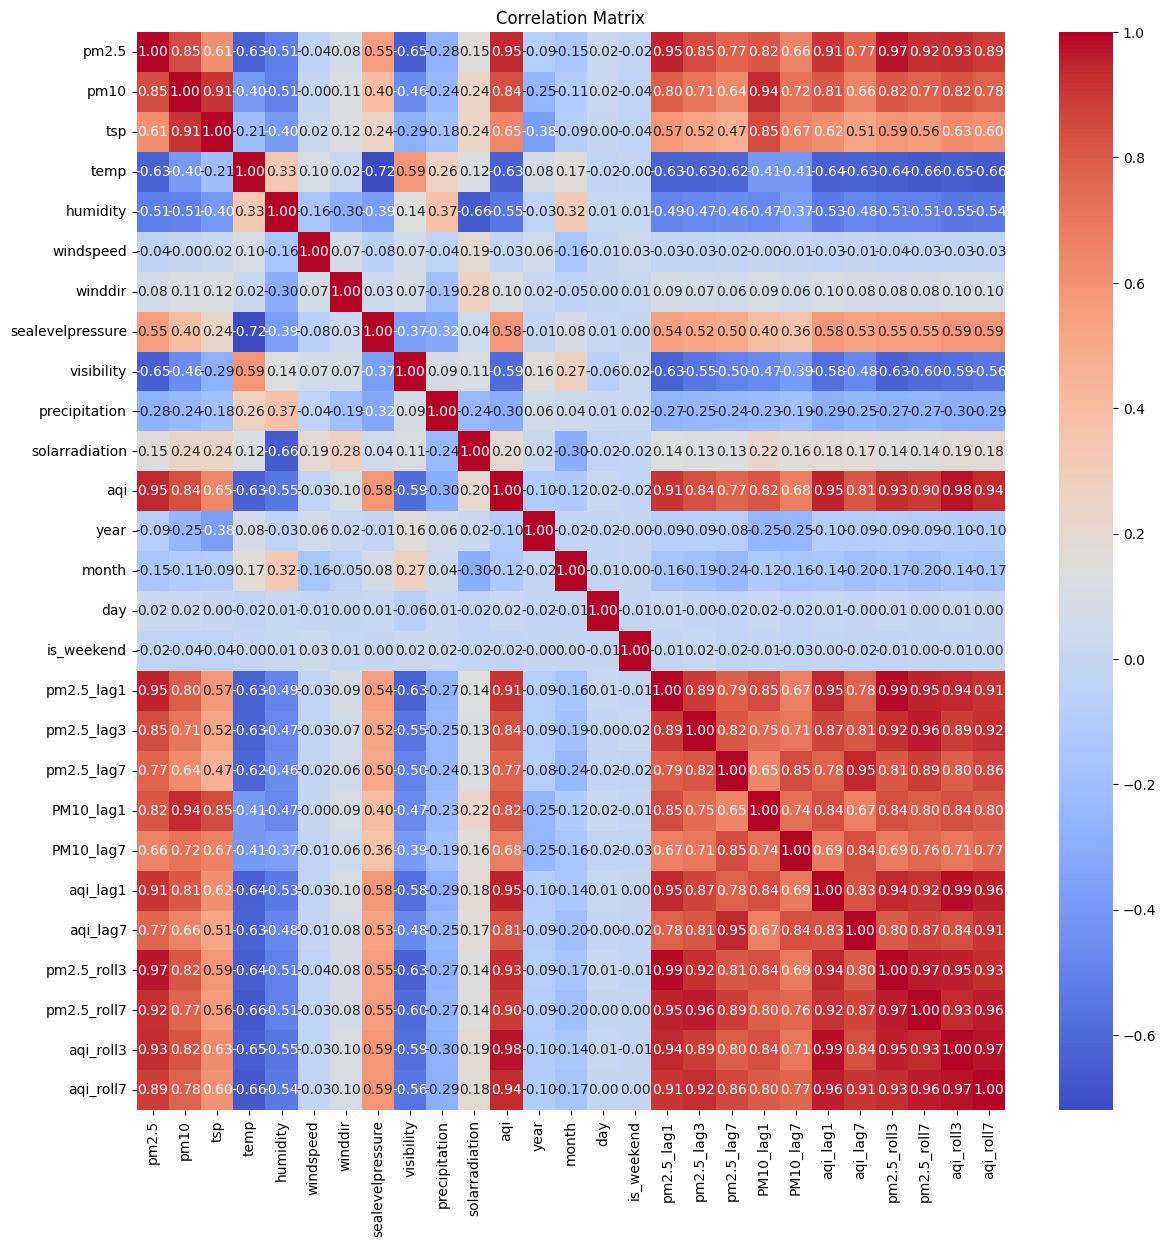

In [32]:
corr_col = df_copy.select_dtypes(include=['number'])
corr_data = corr_col.corr() 
plt.figure(figsize=(14,14))
sns.heatmap(corr_data, annot=True , cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('heatmap.png')
plt.show()

| Feature / Relation | Correlation Strength      | Interpretation                                                                      |
| ------------------ | ------------------------- | ----------------------------------------------------------------------------------- |
| AQI ↔ PM2.5        | Very Strong (+0.95)       | PM2.5 is the dominant AQI-driving pollutant                                         |
| AQI ↔ PM10         | Strong (+0.84)            | PM10 significantly contributes to AQI                                               |
| AQI ↔ Visibility   | Strong Negative (-0.59)   | Higher pollution reduces visibility                                                 |
| AQI ↔ Temperature  | Strong Negative (-0.63)   | Lower temperature associated with higher AQI (winter inversion/stagnant air effect) |
| AQI ↔ Humidity     | Moderate Negative (-0.55) | Higher humidity often linked with cleaner air (monsoon/rainfall influence)          |
| AQI ↔ Pressure     | Moderate Positive (+0.58) | High pressure favors pollution accumulation                                         |
| AQI ↔ Windspeed    | Very Weak (-0.03)         | Windspeed alone has little explanatory power                                        |
| AQI ↔ Weekend      | Near Zero                 | Saturday holiday effect is weak                                                     |
| AQI ↔ Year/Day     | Very Weak                 | AQI depends more on seasonality than year/day                                       |


| Lag / Rolling Feature | Correlation With AQI     | Interpretation                                 |
| --------------------- | ------------------------ | ---------------------------------------------- |
| AQI_lag1              | Very Strong (+0.95)      | Yesterday AQI strongly predicts today AQI      |
| PM2.5_lag1            | Very Strong (+0.91)      | Previous PM2.5 strongly influences current AQI |
| AQI_roll3             | Extremely Strong (+0.98) | Recent AQI trend highly influences current AQI |
| AQI_roll7             | Very Strong (+0.94)      | Weekly AQI trend strongly affects current AQI  |
| PM2.5_roll3           | Extremely Strong (+0.97) | Short-term PM trend highly informative         |
| PM2.5_roll7           | Very Strong (+0.90+)     | Weekly PM trend strongly related to AQI        |


| Overall Observation | Conclusion                                       |
| ------------------- | ------------------------------------------------ |
| PM2.5               | Most important AQI predictor                     |
| Lag Features        | Essential for AQI forecasting                    |
| Rolling Features    | Very useful for capturing pollution trends       |
| Weather Features    | Visibility, temperature, humidity are meaningful |
| Weekend Feature     | Weak but acceptable to keep                      |
| Dataset Quality     | Scientifically realistic and modeling-ready      |
| Multicollinearity   | High, but acceptable for XGBoost                 |


#### AQI Time Series Plot

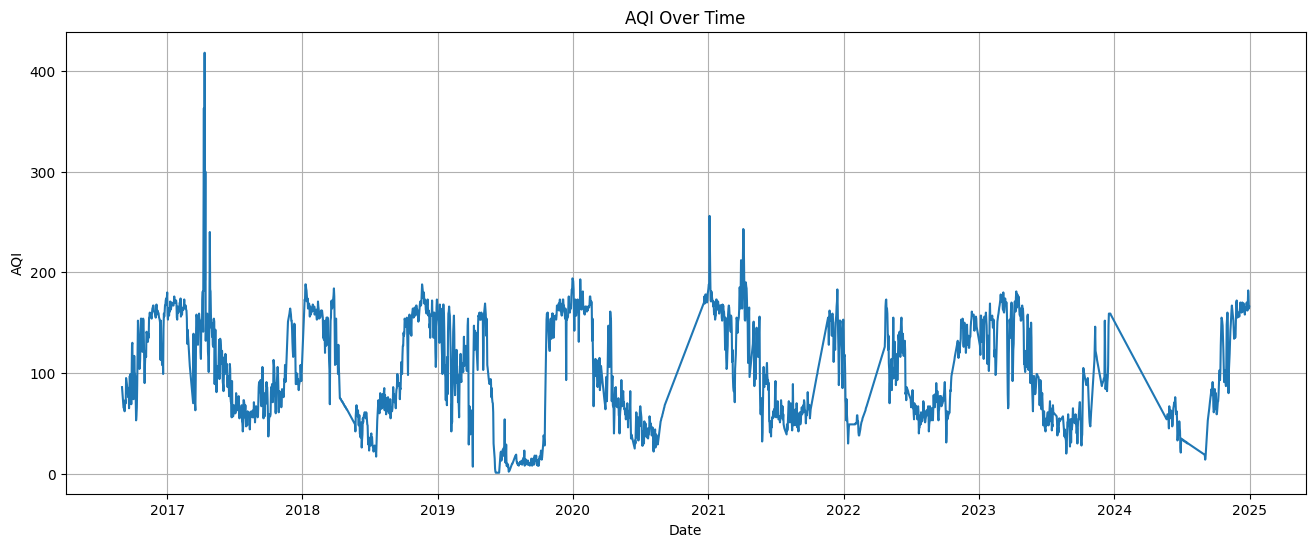

In [37]:
plt.figure(figsize=(16,6))

plt.plot(df_copy['datetime'], df_copy['aqi'])

plt.title('AQI Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')

plt.grid(True)

plt.show()

#### Seasonal AQI Boxplot

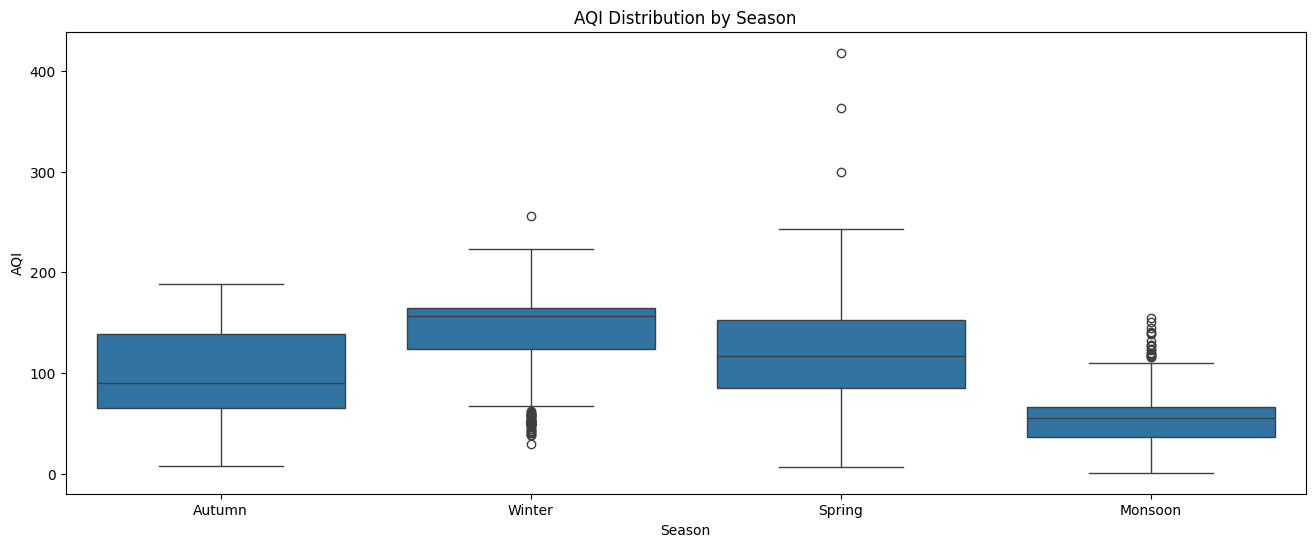

In [42]:
plt.figure(figsize=(16,6))
sns.boxplot(x='season',y='aqi',data=df_copy)
plt.title('AQI Distribution by Season')
plt.xlabel('Season')
plt.ylabel('AQI')

plt.show()

#### Bar Chart

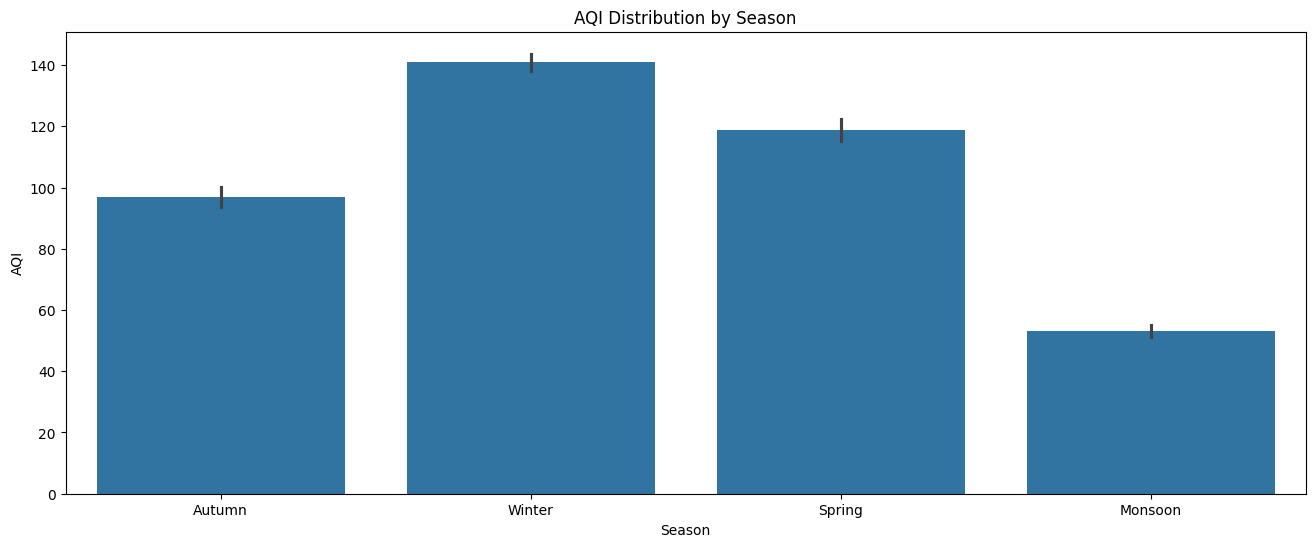

In [43]:
plt.figure(figsize=(16,6))
sns.barplot(x='season',y='aqi',data=df_copy)
plt.title('AQI Distribution by Season')
plt.xlabel('Season')
plt.ylabel('AQI')

plt.show()

#### Monthly AQI Trend

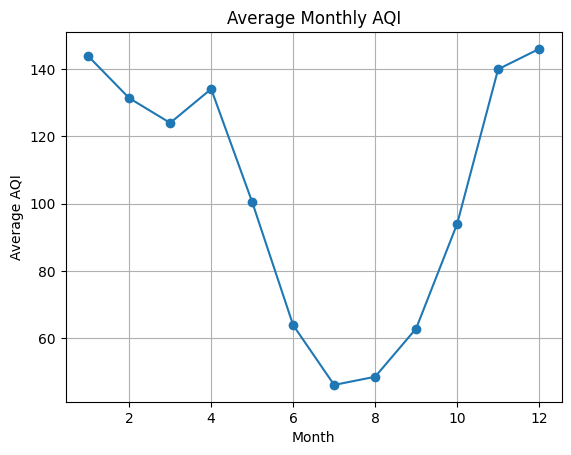

In [44]:
df_plot=df_copy.groupby('month')['aqi'].mean()
df_plot.plot(marker = 'o')
plt.title('Average Monthly AQI (mean)')
plt.xlabel('Month')
plt.ylabel('Average AQI')

plt.grid(True)

plt.show()

#### Current AQI vs AQI Lag1

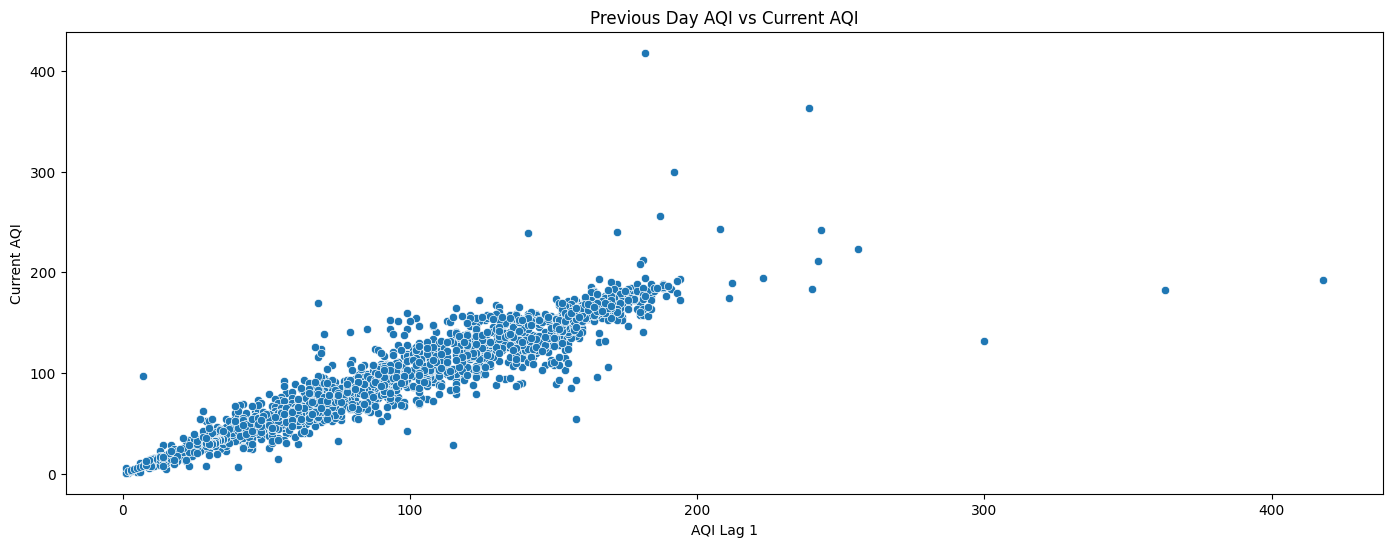

In [51]:
plt.figure(figsize=(17,6))

sns.scatterplot(
    x='aqi_lag1',
    y='aqi',
    data=df_copy
)

plt.title('Previous Day AQI vs Current AQI')

plt.xlabel('AQI Lag 1')
plt.ylabel('Current AQI')

plt.show()

#### PM2.5 Lag1 vs AQI

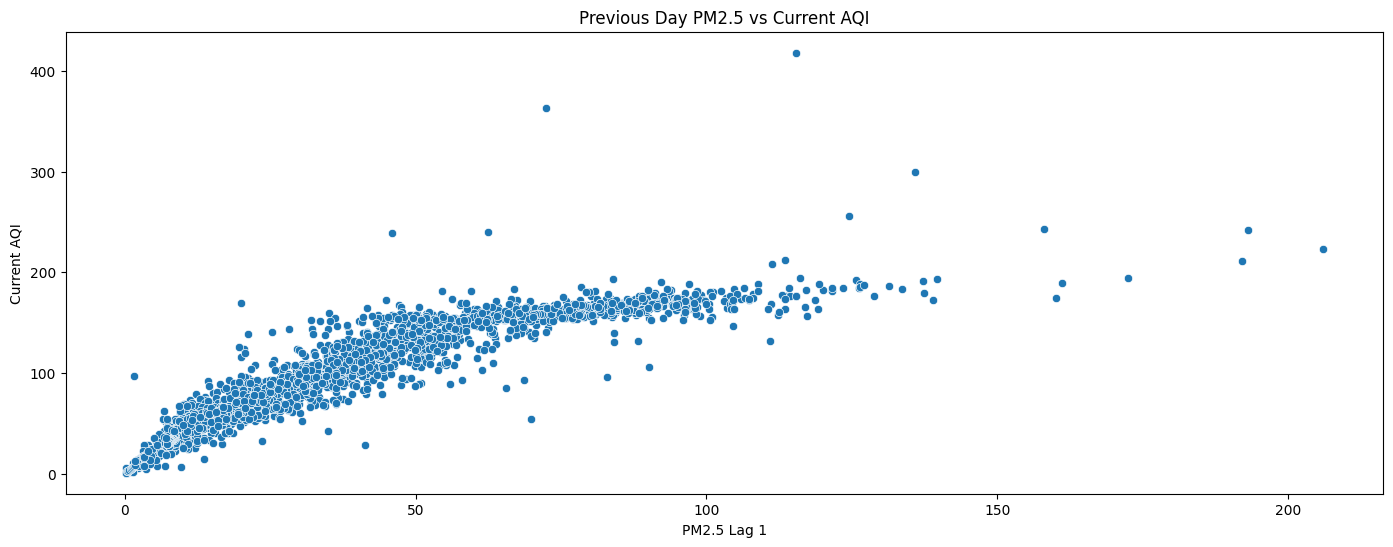

In [52]:
plt.figure(figsize=(17,6))

sns.scatterplot(
    x='pm2.5_lag1',
    y='aqi',
    data=df_copy
)

plt.title('Previous Day PM2.5 vs Current AQI')

plt.xlabel('PM2.5 Lag 1')
plt.ylabel('Current AQI')

plt.show()

#### AQI Distribution

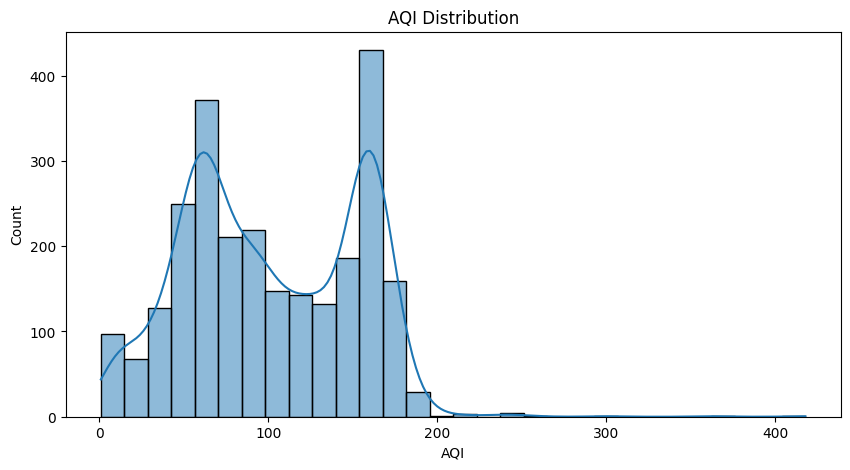

In [47]:

plt.figure(figsize=(10,5))

sns.histplot(
    df_copy['aqi'],
    bins=30,
    kde=True
)

plt.title('AQI Distribution')

plt.xlabel('AQI')

plt.show()

#### Visibility vs AQI

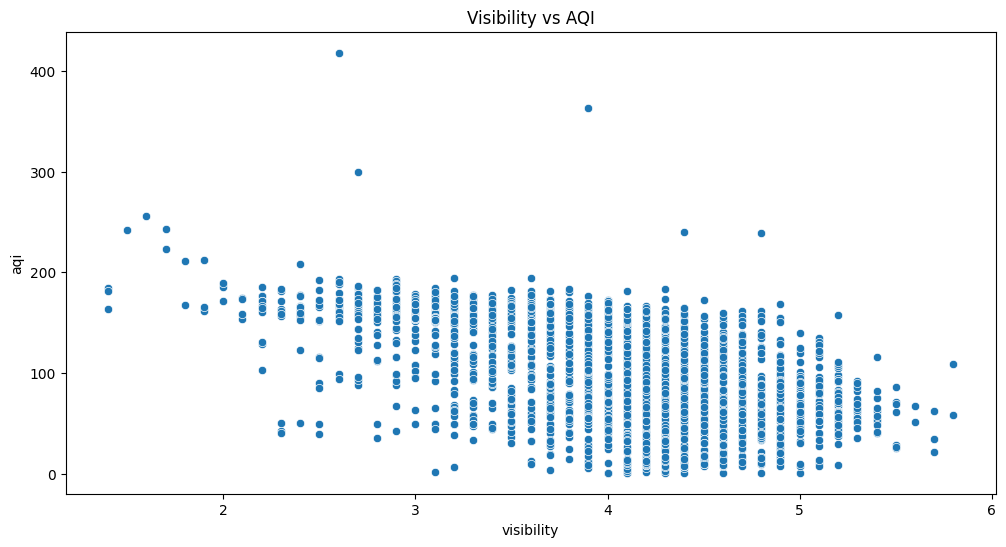

In [53]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x='visibility',
    y='aqi',
    data=df
)

plt.title('Visibility vs AQI')

plt.show()



#### Temperature vs AQI

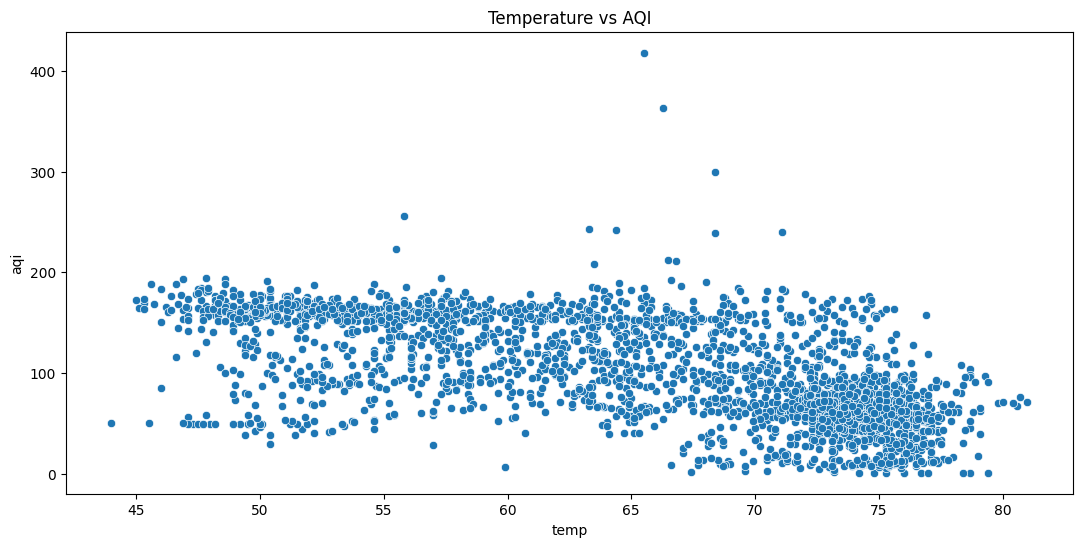

In [54]:

plt.figure(figsize=(13,6))

sns.scatterplot(
    x='temp',
    y='aqi',
    data=df
)

plt.title('Temperature vs AQI')

plt.show()

#### Humidity vs AQI

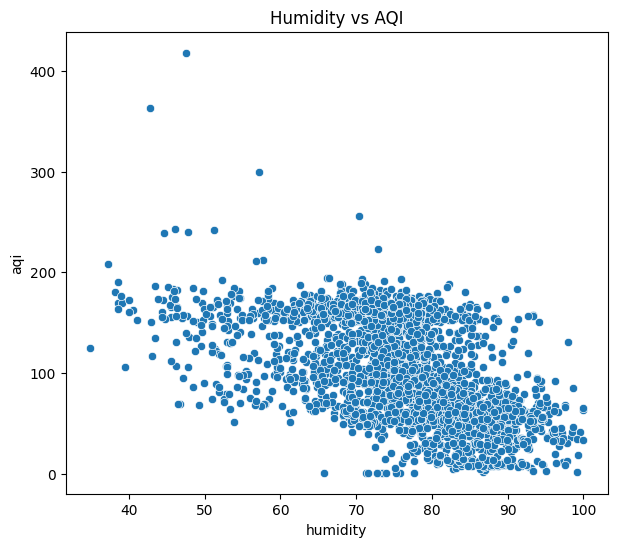

In [50]:

plt.figure(figsize=(7,6))

sns.scatterplot(
    x='humidity',
    y='aqi',
    data=df
)

plt.title('Humidity vs AQI')

plt.show()

| EDA Result                  | Meaning                               |
| --------------------------- | ------------------------------------- |
| Strong seasonality          | AQI depends heavily on season/weather |
| Strong lag relationship     | Temporal forecasting is appropriate   |
| PM2.5 dominance             | PM2.5 is primary AQI driver           |
| Visibility relationship     | Dataset is environmentally realistic  |
| Winter pollution peaks      | Kathmandu inversion effect captured   |
| Monsoon low AQI             | Rainfall cleansing effect captured    |
| Non-normal AQI distribution | Realistic environmental behavior      |
| Extreme outliers exist      | Severe pollution events captured      |


In [55]:
df_copy['month_sin'] = np.sin(2 * np.pi * df_copy['month'] / 12)
df_copy['month_cos'] = np.cos(2 * np.pi * df_copy['month'] / 12)

C:\Users\DELL\AppData\Local\Temp\ipykernel_10660\3479392152.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy['month_sin'] = np.sin(2 * np.pi * df_copy['month'] / 12)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10660\3479392152.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy['month_cos'] = np.cos(2 * np.pi * df_copy['month'] / 12)


In [56]:
df_copy

,datetime,pm2.5,pm10,tsp,temp,humidity,windspeed,winddir,sealevelpressure,visibility,...,PM10_lag1,PM10_lag7,aqi_lag1,aqi_lag7,pm2.5_roll3,pm2.5_roll7,aqi_roll3,aqi_roll7,month_sin,month_cos
7,2016-09-01,28.552393,65.596992,202.183167,74.800003,82.500000,10.3,254.500000,1010.500000,4.3,...,61.884052,131.608307,91.0,89.0,30.922136,28.119885,91.000000,87.714286,-1.000000e+00,-1.836970e-16
8,2016-09-02,26.182652,69.309929,235.702194,75.099998,82.400002,10.3,262.600006,1008.299988,4.9,...,65.596992,111.050743,86.0,79.0,28.552394,28.948221,86.000000,88.000000,-1.000000e+00,-1.836970e-16
9,2016-09-03,23.812908,73.022865,269.221222,72.699997,89.300003,13.9,207.199997,1008.200012,4.0,...,69.309929,90.493179,81.0,69.0,26.182651,29.969825,81.000000,89.000000,-1.000000e+00,-1.836970e-16
10,2016-09-04,21.443167,76.735802,302.740234,71.800003,88.400002,5.8,219.000000,1010.799988,4.3,...,73.022865,86.597778,76.0,92.0,23.812909,28.552394,76.000000,86.000000,-1.000000e+00,-1.836970e-16
11,2016-09-05,19.073425,80.448738,336.259247,74.099998,84.300003,8.1,197.300003,1010.799988,4.4,...,76.735802,54.458179,71.0,101.0,21.443167,26.182651,71.000000,81.000000,-1.000000e+00,-1.836970e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2641,2024-12-27,90.031288,122.154243,161.637466,52.500000,69.400002,4.7,160.800003,1024.099976,3.7,...,109.378380,121.439789,162.0,165.0,84.536702,83.960883,166.000000,165.857143,-2.449294e-16,1.000000e+00
2642,2024-12-28,115.462082,150.554245,191.303696,51.500000,76.599998,4.7,131.100006,1023.799988,2.8,...,122.154243,104.772743,169.0,162.0,94.276031,89.553929,171.000000,168.714286,-2.449294e-16,1.000000e+00
2643,2024-12-29,104.691322,139.022644,201.824020,54.799999,68.300003,11.4,257.399994,1021.400024,3.3,...,150.554245,105.436142,182.0,163.0,103.394897,93.292337,175.666667,170.571429,-2.449294e-16,1.000000e+00
2644,2024-12-30,81.418266,107.658470,139.620422,52.400002,71.099998,8.1,204.300003,1020.500000,4.1,...,139.022644,115.394096,176.0,168.0,100.523890,92.386107,174.000000,170.000000,-2.449294e-16,1.000000e+00


In [57]:
df_copy.to_csv('Feature_Ready_dataset.csv',index=False)